# 02 · Binary response knowledge distillation for Student-120

**Single responsibility:** measure whether Hinton-style response distillation improves the exact
Student-120 graph established by Notebook 01. The primary paper-derived run uses the MicroNets
Visual Wake Words anchor $T=4$ and $\lambda=0.5$.

This notebook changes the **training objective only**. Student architecture, native-image identity,
120×120 RGB preprocessing, augmentation, ImageNet initialization policy, two-stage training budget,
validation threshold rule, test split, and INT8 export contract remain controlled.

## Experimental isolation

```mermaid
flowchart LR
    J[Native JPEG + immutable image_id] --> S[Student view\n120×120 RGB]
    C[Cached Teacher-160 logit\njoined by image_id] --> T[Temperature scaling\nsigmoid z_t / T]
    S --> M[Student-120\nMobileNetV1 alpha 0.25]
    M --> Z[Student logit z_s]
    Y[Hard VWW label y] --> H[Hard BCE\nT = 1]
    Z --> H
    Z --> Q[Soft BCE\nT = 4]
    T --> Q
    H --> L[Weighted total loss]
    Q --> L
    L --> F[Selected float KD student]
    F --> I[Full INT8 PTQ]
    I --> D[Physical profiling\nseparate evidence]
```

The teacher is frozen and never exported. At inference the student uses temperature 1, so the
deployable graph has the same topology and theoretical cost as the hard-label control.

## Paper-to-code traceability

| Source | Paper statement used here | Notebook implementation |
|---|---|---|
| Hinton, Vinyals & Dean (2015) | Match softened teacher targets and hard labels; use the same high temperature for teacher/student; multiply the soft term by $T^2$ | Bernoulli KL (soft cross-entropy minus constant teacher entropy) in `BinaryResponseDistiller._loss_terms` |
| MicroNets (MLSys 2021) | VWW fine-tuning uses teacher coefficient 0.5 and temperature 4 | Registered anchor `temperature=4`, `teacher_loss_weight=0.5` |
| Notebook 01 hard control | Same student and experimental budget without teacher gradients | Frozen counterfactual baseline |

Local sources:

- `papers/distillation/01_hinton_distilling_knowledge_2015.pdf`
- `papers/distillation/09_micronets_tinyml_architectures_2021.pdf`

MicroNets also uses architecture search, grayscale inputs, QAT, and different MCU targets. Those
components are deliberately **not** imported into this experiment because they would confound the
effect of response distillation.

## Mathematical objective

For hard label $y\in\{0,1\}$, cached teacher logit $z_t$, student logit $z_s$, temperature $T$, and
teacher-loss weight $\lambda$:

$$p_s=\sigma(z_s),\qquad q_t^{(T)}=\sigma(z_t/T),\qquad q_s^{(T)}=\sigma(z_s/T).$$

$$\mathcal L_{hard}=\operatorname{BCE}(\tilde y,p_s),$$

$$\mathcal L_{soft}=D_{KL}\!\left(\operatorname{Ber}(q_t^{(T)})\,\|\,\operatorname{Ber}(q_s^{(T)})\right).$$

$$\boxed{\mathcal L=(1-\lambda)\mathcal L_{hard}+\lambda T^2\mathcal L_{soft}+\mathcal L_{L2}}.$$

The label-smoothed target $\tilde y$ and $L_2$ regularization are inherited from Notebook 01.
The $T^2$ factor compensates for the approximately $1/T^2$ reduction in soft-target gradients.
For this binary task, Bernoulli KL equals the paper's soft cross-entropy minus the teacher entropy.
Teacher entropy is constant with respect to the student, so the gradient is exactly the same while
the logged soft loss is zero when student and teacher distributions match.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/vww-matplotlib')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '1')
current = Path.cwd().resolve()
ROOT = next(candidate for candidate in (current, *current.parents) if (candidate / 'pyproject.toml').exists())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
print(f'Repository: {ROOT}')

Repository: /Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32


In [2]:
import hashlib
import json
import platform
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import yaml
from IPython.display import Markdown, display
from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve, roc_curve

from vww_esp32.config import seed_everything
from vww_esp32.evaluation import (
    calibration_points,
    classification_metrics,
    expected_calibration_error,
    select_threshold,
)
from vww_esp32.exporting import convert_full_integer, inspect_tflite
from vww_esp32.profiling import profile_model

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 100)
print({'tensorflow': tf.__version__, 'python': platform.python_version()})

{'tensorflow': '2.20.0', 'python': '3.10.13'}


## 1 · Load and freeze the experiment contract

The control configuration is not copied informally. Notebook 02 records hashes for its own
configuration, the manifest, teacher, cached logits, and Notebook 01 model/summary. Any mismatch
creates a new experiment rather than silently reusing an old checkpoint.

In [3]:
CONFIG_PATH = ROOT / 'configs/distillation_response_kd_120.yaml'

In [4]:
with CONFIG_PATH.open(encoding='utf-8') as handle:
    config = yaml.safe_load(handle)

In [5]:
SEED = int(config['project']['seed'])
TEACHER_SIZE = tuple(config['teacher']['image_size'])
STUDENT_SIZE = tuple(config['student']['image_size'])
BATCH_SIZE = int(config['preprocessing']['batch_size'])
TEMPERATURE = float(config['distillation']['temperature'])
TEACHER_WEIGHT = float(config['distillation']['teacher_loss_weight'])

ARTIFACT_DIR = ROOT / config['paths']['artifacts']
CHECKPOINT_DIR = ARTIFACT_DIR / 'checkpoints'
FIGURE_DIR = ARTIFACT_DIR / 'figures'
MODEL_DIR = ARTIFACT_DIR / 'models'
REPORT_DIR = ARTIFACT_DIR / 'reports'
LOG_DIR = ARTIFACT_DIR / 'logs'

In [6]:
for directory in (CHECKPOINT_DIR, FIGURE_DIR, MODEL_DIR, REPORT_DIR, LOG_DIR):
    directory.mkdir(parents=True, exist_ok=True)

In [7]:
# Mirrors Notebook 01: Run All trains the registered paper-derived anchor.
RUN_TRAINING = True
REUSE_BEST_CHECKPOINT = True
RUN_EXPORT = True
RUN_BOOTSTRAP = True
seed_everything(SEED)
print({
    'teacher_size': TEACHER_SIZE,
    'student_size': STUDENT_SIZE,
    'batch_size': BATCH_SIZE,
    'temperature': TEMPERATURE,
    'teacher_weight': TEACHER_WEIGHT,
    'run_training': RUN_TRAINING,
})

{'teacher_size': (160, 160), 'student_size': (120, 120), 'batch_size': 32, 'temperature': 4.0, 'teacher_weight': 0.5, 'run_training': True}


In [8]:
def sha256_file(path, chunk_bytes=1 << 20):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(chunk_bytes), b''):
            digest.update(chunk)
    return digest.hexdigest()


def sha256_weights(model):
    digest = hashlib.sha256()
    for weight in model.weights:
        array = np.asarray(weight.numpy())
        digest.update(weight.name.encode())
        digest.update(str(array.shape).encode())
        digest.update(array.tobytes())
    return digest.hexdigest()

In [9]:
MANIFEST_PATH = ROOT / config['paths']['manifest']
TEACHER_MODEL_PATH = ROOT / config['paths']['teacher_model']
TEACHER_TARGETS_PATH = ROOT / config['paths']['teacher_targets']
TEACHER_SUMMARY_PATH = ROOT / config['paths']['teacher_summary']
CONTROL_MODEL_PATH = ROOT / config['paths']['control_model']
CONTROL_SUMMARY_PATH = ROOT / config['paths']['control_summary']
CONTROL_STATIC_PATH = ROOT / config['paths']['control_static_profile']
REFERENCE_PATHS = {
    'hinton_2015': ROOT / config['references']['hinton_2015'],
    'micronets_2021': ROOT / config['references']['micronets_2021'],
}
required_paths = [
    MANIFEST_PATH, TEACHER_MODEL_PATH, TEACHER_TARGETS_PATH, TEACHER_SUMMARY_PATH,
    CONTROL_MODEL_PATH, CONTROL_SUMMARY_PATH, CONTROL_STATIC_PATH, *REFERENCE_PATHS.values(),
]
missing = [str(path) for path in required_paths if not path.exists()]
assert not missing, f'Missing prerequisite artifacts: {missing}'

In [10]:
runtime_contract = {
    'experiment': config['project']['name'],
    'config_sha256': sha256_file(CONFIG_PATH),
    'manifest_sha256': sha256_file(MANIFEST_PATH),
    'teacher_model_sha256': sha256_file(TEACHER_MODEL_PATH),
    'teacher_targets_sha256': sha256_file(TEACHER_TARGETS_PATH),
    'control_model_sha256': sha256_file(CONTROL_MODEL_PATH),
    'control_summary_sha256': sha256_file(CONTROL_SUMMARY_PATH),
    'paper_sha256': {name: sha256_file(path) for name, path in REFERENCE_PATHS.items()},
    'python': platform.python_version(),
    'tensorflow': tf.__version__,
    'seed': SEED,
    'teacher_input': [*TEACHER_SIZE, 3],
    'student_input': [*STUDENT_SIZE, 3],
    'temperature': TEMPERATURE,
    'teacher_loss_weight': TEACHER_WEIGHT,
    'temperature_squared_scaling': True,
    'inference_temperature': 1.0,
}
(REPORT_DIR / 'runtime_contract.json').write_text(json.dumps(runtime_contract, indent=2) + '\n')
display(pd.Series(runtime_contract))

experiment                                           vww-response-kd-student-120
config_sha256                  a9dee2517276e983cbea4dedcb751cb537c721bfb8bd27...
manifest_sha256                6e25ac1d8c6b98ccc54f188e7d38ce34c9c711d1bc2242...
teacher_model_sha256           8f8e0d7035e58abb710f8472ca5869bc14ebbd6dfea03c...
teacher_targets_sha256         1bdf01ac3479958836875171895ef61c48edb05b360dd9...
control_model_sha256           a85a696243a020aec132d11ecf0f218203066e4259f2e1...
control_summary_sha256         30387ee95cac5c7ff884eaaef0ad63b85cbf2b9a854422...
paper_sha256                   {'hinton_2015': '74e6689115c539db499f9d6153ede...
python                                                                   3.10.13
tensorflow                                                                2.20.0
seed                                                                          42
teacher_input                                                      [160, 160, 3]
student_input               

## 2 · Audit the teacher cache and hard-control evidence

Cached logits are joined by immutable `image_id`, never by CSV row position. Logits are retained
because temperature must be applied before sigmoid. Applying temperature to an already rounded or
clipped probability would discard teacher information.

In [11]:
manifest = pd.read_csv(MANIFEST_PATH)
targets = pd.read_csv(TEACHER_TARGETS_PATH)
teacher_summary = json.loads(TEACHER_SUMMARY_PATH.read_text())
control_summary = json.loads(CONTROL_SUMMARY_PATH.read_text())
control_static = json.loads(CONTROL_STATIC_PATH.read_text())

In [12]:
required_manifest = {
    'image_id', 'image_path', 'split', 'label', 'width', 'height',
    'aspect_ratio', 'max_person_area_fraction',
}
required_targets = {'image_id', 'split', 'label', 'teacher_probability', 'teacher_logit'}
assert required_manifest <= set(manifest)
assert required_targets <= set(targets)
assert manifest.image_id.is_unique and targets.image_id.is_unique
assert set(manifest.image_id) == set(targets.image_id)

In [13]:
kd_frame = manifest.merge(
    targets[['image_id', 'split', 'label', 'teacher_probability', 'teacher_logit']],
    on='image_id',
    suffixes=('', '_teacher'),
    validate='one_to_one',
)
assert (kd_frame.split == kd_frame.split_teacher).all()
assert (kd_frame.label == kd_frame.label_teacher).all()
assert np.isfinite(kd_frame[['teacher_probability', 'teacher_logit']]).all().all()
assert kd_frame.teacher_probability.between(0, 1).all()
assert bool(teacher_summary['approved_for_distillation'])
assert bool(control_summary['ready_for_response_kd'])
assert kd_frame.image_path.map(lambda value: Path(value).exists()).all()

In [14]:
splits = {
    name: kd_frame[kd_frame.split == name].sort_values('image_id').reset_index(drop=True)
    for name in ('train', 'val', 'test')
}
split_summary = kd_frame.groupby('split').agg(
    samples=('image_id', 'size'),
    positives=('label', 'sum'),
    teacher_probability_mean=('teacher_probability', 'mean'),
    teacher_logit_std=('teacher_logit', 'std'),
)
split_summary['positive_fraction'] = split_summary.positives / split_summary.samples
split_summary.to_csv(REPORT_DIR / 'dataset_and_teacher_summary.csv')
display(split_summary)

,samples,positives,teacher_probability_mean,teacher_logit_std,positive_fraction
split,,,,,
test,2000,981,0.457859,2.718324,0.4905
train,12000,6000,0.476659,2.733698,0.5000
val,2000,989,0.481005,2.722838,0.4945


In [15]:
def sigmoid_np(values):
    values = np.asarray(values, dtype=np.float64)
    return np.where(values >= 0, 1 / (1 + np.exp(-values)), np.exp(values) / (1 + np.exp(values)))

In [16]:
def binary_entropy_np(probabilities, epsilon=1e-7):
    p = np.clip(np.asarray(probabilities), epsilon, 1 - epsilon)
    return -(p * np.log(p) + (1 - p) * np.log(1 - p))

In [17]:
temperature_rows = []

In [18]:
for temperature in (1.0, 2.0, 4.0, 8.0):
    softened = sigmoid_np(splits['train'].teacher_logit / temperature)
    temperature_rows.append({
        'temperature': temperature,
        'probability_mean': softened.mean(),
        'probability_std': softened.std(),
        'mean_entropy_nats': binary_entropy_np(softened).mean(),
        'fraction_extreme': np.mean((softened < 0.05) | (softened > 0.95)),
    })

In [19]:
temperature_audit = pd.DataFrame(temperature_rows)
temperature_audit.to_csv(REPORT_DIR / 'teacher_temperature_audit.csv', index=False)
display(temperature_audit.style.format({
    'probability_mean': '{:.4f}', 'probability_std': '{:.4f}',
    'mean_entropy_nats': '{:.4f}', 'fraction_extreme': '{:.2%}',
}))

,temperature,probability_mean,probability_std,mean_entropy_nats,fraction_extreme
0,1.000000,0.4767,0.3693,0.3606,29.18%
1,2.000000,0.5003,0.2639,0.5384,2.19%
2,4.000000,0.5062,0.1571,0.6417,0.00%
3,8.000000,0.5044,0.0835,0.6790,0.00%


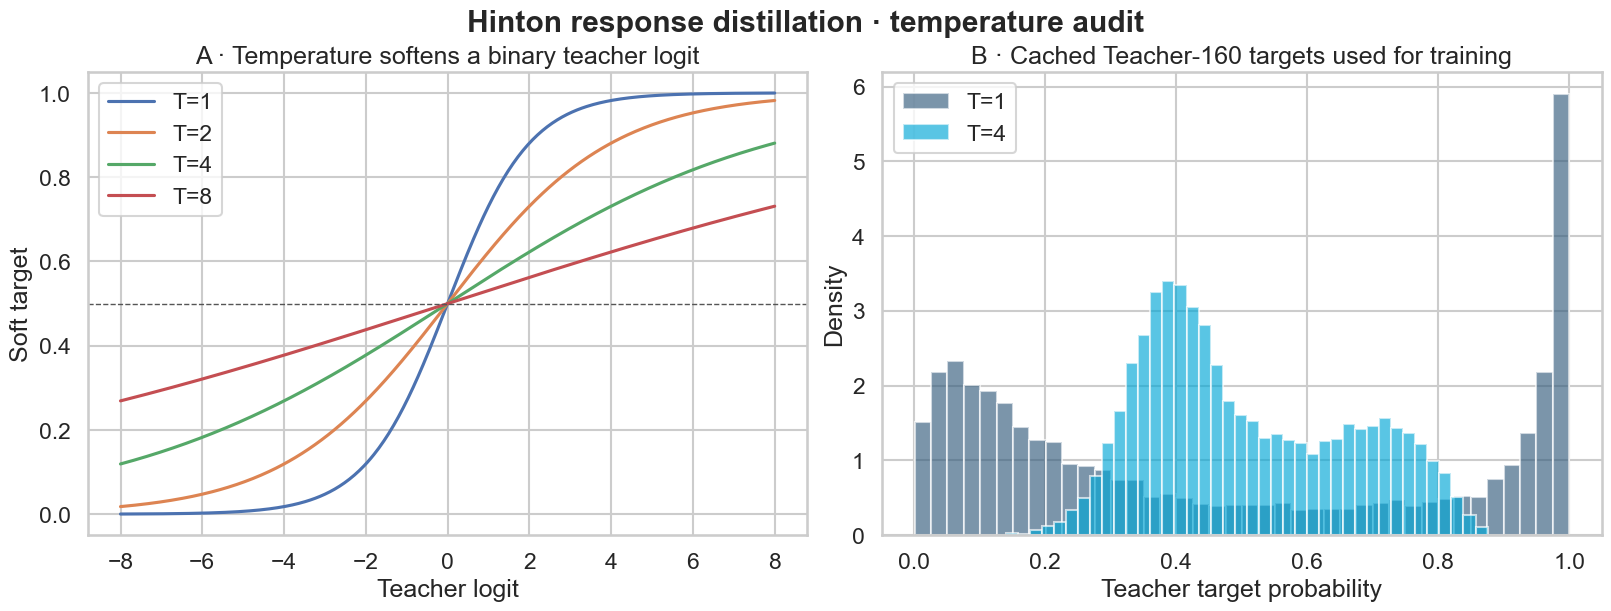

In [20]:
sample_logits = np.linspace(-8, 8, 401)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
for temperature in (1.0, 2.0, 4.0, 8.0):
    axes[0].plot(sample_logits, sigmoid_np(sample_logits / temperature), label=f'T={temperature:g}')
axes[0].axhline(.5, color='#555555', linestyle='--', linewidth=1)
axes[0].set(title='A · Temperature softens a binary teacher logit', xlabel='Teacher logit', ylabel='Soft target')
axes[0].legend()

for temperature, color in [(1.0, '#355C7D'), (4.0, '#00A6D6')]:
    values = sigmoid_np(splits['train'].teacher_logit / temperature)
    axes[1].hist(values, bins=40, alpha=.65, density=True, label=f'T={temperature:g}', color=color)
axes[1].set(title='B · Cached Teacher-160 targets used for training', xlabel='Teacher target probability', ylabel='Density')
axes[1].legend()
fig.suptitle('Hinton response distillation · temperature audit', fontweight='bold')
fig.savefig(FIGURE_DIR / 'teacher_temperature_softening.png', dpi=180, bbox_inches='tight')
plt.show()

## 3 · Immutable-image preprocessing and KD datasets

The student still receives the 120×120 firmware-compatible view from Notebook 01. The cached
teacher logit is metadata associated with `image_id`; no 160×160 teacher forward pass occurs during
student training. This avoids GPU/CPU teacher overhead and prevents row-order corruption.

In [21]:
AUTOTUNE = tf.data.AUTOTUNE

In [22]:
def decode_letterbox_image(path, size, antialias):
    image = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    image = tf.image.resize_with_pad(
        image, size[0], size[1],
        method=config['preprocessing']['resize_method'],
        antialias=bool(antialias),
    )
    image = tf.cast(tf.clip_by_value(image, 0, 255), tf.float32)
    image.set_shape((*size, 3))
    return image

In [23]:
def make_eval_dataset(
        frame, 
        batch_size=BATCH_SIZE
):
    ds = tf.data.Dataset.from_tensor_slices(
        (
            frame.image_path.astype(str).to_numpy(),
            frame.label.astype('float32').to_numpy(),
        )
    )
    options = tf.data.Options()
    options.experimental_deterministic = True

    ds = ds.with_options(options)
    ds = ds.map(
        lambda path, label: (
            decode_letterbox_image(
                path, 
                STUDENT_SIZE, 
                config['preprocessing']['student_antialias']
            ),
            tf.cast(label, tf.float32),
        ),
        num_parallel_calls=AUTOTUNE,
    )
    
    return ds.batch(batch_size).prefetch(AUTOTUNE)

In [24]:
def make_kd_dataset(
        frame, 
        training=False, 
        batch_size=BATCH_SIZE
):
    # TARGETS
    targets_dict = {
        'label': frame.label.astype('float32').to_numpy(),
        'teacher_logit': frame.teacher_logit.astype('float32').to_numpy(),
    }

    ds = tf.data.Dataset.from_tensor_slices((frame.image_path.astype(str).to_numpy(), targets_dict))
    
    options = tf.data.Options()
    options.experimental_deterministic = not training
    
    ds = ds.with_options(options)

    # Shuffle
    if training:
        ds = ds.shuffle(
            min(len(frame), 4096), 
            seed=SEED, 
            reshuffle_each_iteration=True
        )
    
    ds = ds.map(
        lambda path, target: (
            decode_letterbox_image(path, STUDENT_SIZE, config['preprocessing']['student_antialias']),
            {
                'label': tf.cast(target['label'], tf.float32),
                'teacher_logit': tf.cast(target['teacher_logit'], tf.float32)
            },
        ),
        num_parallel_calls=AUTOTUNE,
    )
    return ds.batch(batch_size).prefetch(AUTOTUNE)

In [25]:
train_kd_ds = make_kd_dataset(splits['train'], training=True)
val_kd_ds = make_kd_dataset(splits['val'])
train_eval_ds = make_eval_dataset(splits['train'])
val_ds = make_eval_dataset(splits['val'])
test_ds = make_eval_dataset(splits['test'])

In [26]:
batch_images, batch_targets = next(iter(val_kd_ds))

In [27]:
assert batch_images.shape[1:] == (*STUDENT_SIZE, 3)
assert batch_targets['label'].shape == batch_targets['teacher_logit'].shape
assert np.allclose(
    sigmoid_np(batch_targets['teacher_logit'].numpy()),
    splits['val'].teacher_probability.iloc[:len(batch_targets['label'])].to_numpy(),
    atol=2e-6,
)
print({
    'images': tuple(batch_images.shape),
    'labels': tuple(batch_targets['label'].shape),
    'teacher_logits': tuple(batch_targets['teacher_logit'].shape),
    'pixel_range': (float(tf.reduce_min(batch_images)), float(tf.reduce_max(batch_images))),
})

{'images': (32, 120, 120, 3), 'labels': (32,), 'teacher_logits': (32,), 'pixel_range': (0.0, 255.0)}


In [28]:
preview = pd.concat([
    splits['train'][splits['train'].label == 0].head(4),
    splits['train'][splits['train'].label == 1].head(4),
]).sort_values(['label', 'image_id'])
preview_images = next(iter(make_eval_dataset(preview, batch_size=8)))[0].numpy().astype(np.uint8)

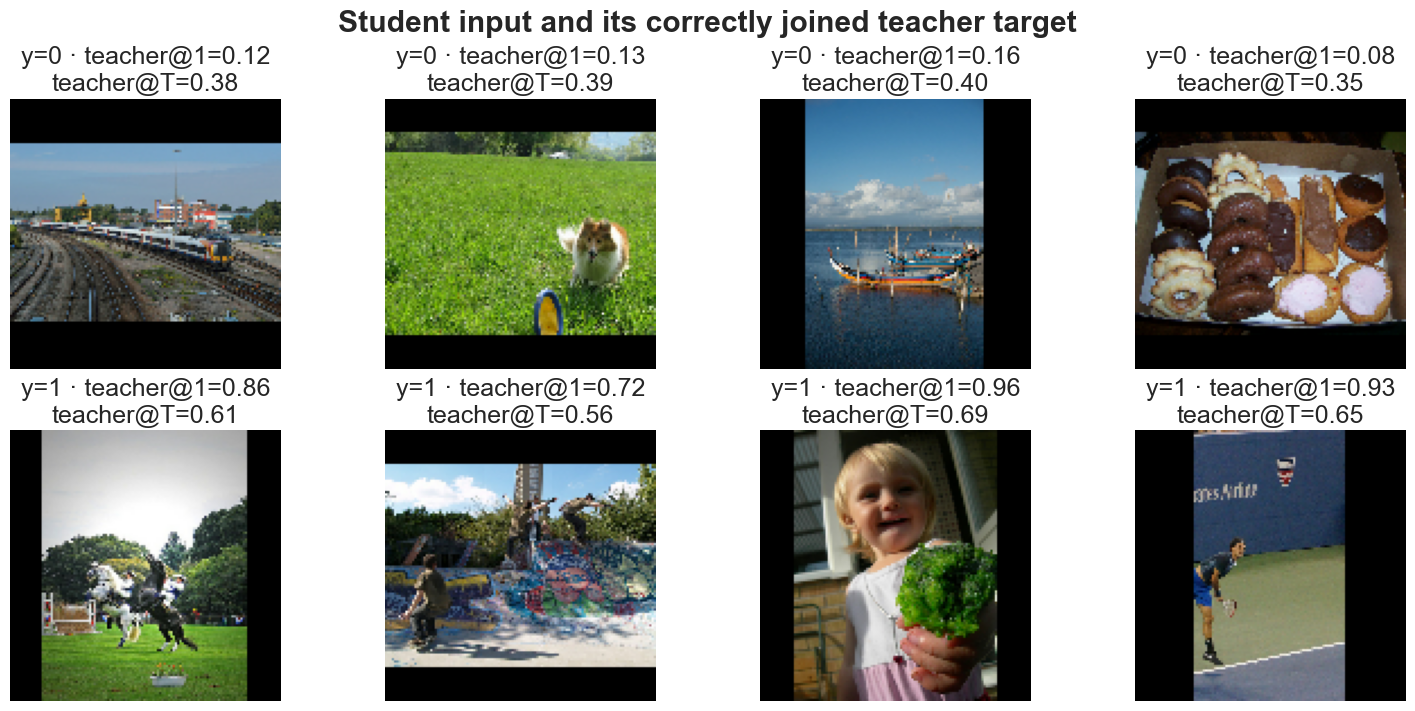

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7), constrained_layout=True)
for axis, image, row in zip(axes.flat, preview_images, preview.itertuples()):
    axis.imshow(image)
    soft = sigmoid_np(row.teacher_logit / TEMPERATURE)
    axis.set_title(f'y={row.label} · teacher@1={row.teacher_probability:.2f}\nteacher@T={soft:.2f}')
    axis.axis('off')
fig.suptitle('Student input and its correctly joined teacher target', fontweight='bold')
fig.savefig(FIGURE_DIR / 'kd_input_target_alignment.png', dpi=180, bbox_inches='tight')
plt.show()

## 4 · Rebuild the exact Student-120 topology

The trainable model exposes raw `person_logit`, because temperature must be applied to logits.
The deployable view adds the same sigmoid output as Notebook 01. MobileNetV1 width, RGB resolution,
normalization, augmentation, dropout, and regularization are unchanged.

In [30]:
aug = config['augmentation']
augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip('horizontal', seed=SEED),
        tf.keras.layers.RandomTranslation(
            aug['translation_fraction'], aug['translation_fraction'],
            fill_mode='reflect', seed=SEED + 1,
        ),
        tf.keras.layers.RandomBrightness(
            aug['brightness_delta'], value_range=(-1, 1), seed=SEED + 2,
        ),
        tf.keras.layers.RandomContrast(aug['contrast_factor'], seed=SEED + 3),
        tf.keras.layers.RandomSaturation(
            aug['saturation_factor'], value_range=(-1, 1), seed=SEED + 4,
        ),
        tf.keras.layers.GaussianNoise(aug['sensor_noise_stddev'], seed=SEED + 5),
    ],
    name='camera_augmentation',
)

In [31]:
def build_student_core(weights='imagenet'):
    # INPUTS
    inputs = tf.keras.Input(
        (*STUDENT_SIZE, 3), 
        name='image'
    )

    x = tf.keras.layers.Rescaling(1 / 127.5, offset=-1, name='normalize')(inputs)
    x = augmentation(x)
    
    backbone = tf.keras.applications.MobileNet(
        input_tensor=x,
        input_shape=(*STUDENT_SIZE, 3),
        alpha=float(config['student']['width_multiplier']),
        include_top=False,
        weights=weights,
    )
    
    x = tf.keras.layers.GlobalAveragePooling2D(name='global_average')(backbone.output)
    x = tf.keras.layers.Dropout(float(config['student']['dropout']), name='student_dropout')(x)

    # OUTPUTS
    logits = tf.keras.layers.Dense(
        1,
        kernel_regularizer=tf.keras.regularizers.l2(float(config['student']['l2'])),
        name='person_logit',
    )(x)
    core = tf.keras.Model(
        inputs, 
        logits, 
        name='vww_student_120_a025_response_kd_logits'
    )
    
    return core, backbone

In [32]:
def probability_view(core, name='vww_student_120_a025_response_kd'):
    probability = tf.keras.layers.Activation(
        'sigmoid', 
        name='person_probability'
    )(core.output)
    return tf.keras.Model(
        core.input, 
        probability, 
        name=name
    )

In [33]:
# Re-seed immediately before construction so the KD run reproduces the registered initialization policy.
seed_everything(SEED)

In [34]:
student_core, backbone = build_student_core(
    'imagenet' if config['student']['imagenet_initialization'] else None
)

/var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/ipykernel_41597/1772937007.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = tf.keras.applications.MobileNet(


In [35]:
student_probability = probability_view(student_core)

In [36]:
backbone_names = {layer.name for layer in backbone.layers}
initialization_sha256 = sha256_weights(student_core)
print({'parameters': student_probability.count_params(), 'initialization_sha256': initialization_sha256})

{'parameters': 218801, 'initialization_sha256': 'bfa23c133c71af3ca0ffa97488571f2cd66e93001d24a0a5bd6504d8a9310895'}


In [37]:
control_model = tf.keras.models.load_model(CONTROL_MODEL_PATH, compile=False)

In [38]:
def weighted_layer_signature(model):
    return [
        (layer.name, layer.__class__.__name__, [tuple(weight.shape) for weight in layer.weights])
        for layer in model.layers if layer.weights
    ]


In [39]:
assert student_probability.count_params() == control_model.count_params() == 218801
assert weighted_layer_signature(student_probability) == weighted_layer_signature(control_model)
print('Architecture invariant: PASS — same weighted layers and parameter shapes as hard control.')

Architecture invariant: PASS — same weighted layers and parameter shapes as hard control.


In [40]:
layers, liveness, static_profile = profile_model(
    student_probability,
    batch_size=1,
    training_batch_size=BATCH_SIZE,
)

In [41]:
assert static_profile['parameters'] == control_static['parameters']
assert static_profile['estimated_macs_batch1'] == control_static['estimated_macs_batch1']

In [42]:
layers.to_csv(REPORT_DIR / 'student_layer_profile_untrained.csv', index=False)
liveness.to_csv(REPORT_DIR / 'student_activation_liveness_untrained.csv', index=False)
(REPORT_DIR / 'student_static_profile_untrained.json').write_text(json.dumps(static_profile, indent=2) + '\n')
display(pd.DataFrame([
    {'model': 'Hard control', **{key: control_static[key] for key in ['parameters', 'estimated_macs_batch1', 'peak_live_activation_int8_bytes_batch1_hypothetical']}},
    {'model': 'Response KD', **{key: static_profile[key] for key in ['parameters', 'estimated_macs_batch1', 'peak_live_activation_int8_bytes_batch1_hypothetical']}},
]))

,model,parameters,estimated_macs_batch1,peak_live_activation_int8_bytes_batch1_hypothetical
0,Hard control,218801,10487648,117136
1,Response KD,218801,10487648,117136


In [43]:
top = layers[
    layers.estimated_macs_batch1 > 0
].nlargest(16, 'estimated_macs_batch1').sort_values('estimated_macs_batch1')

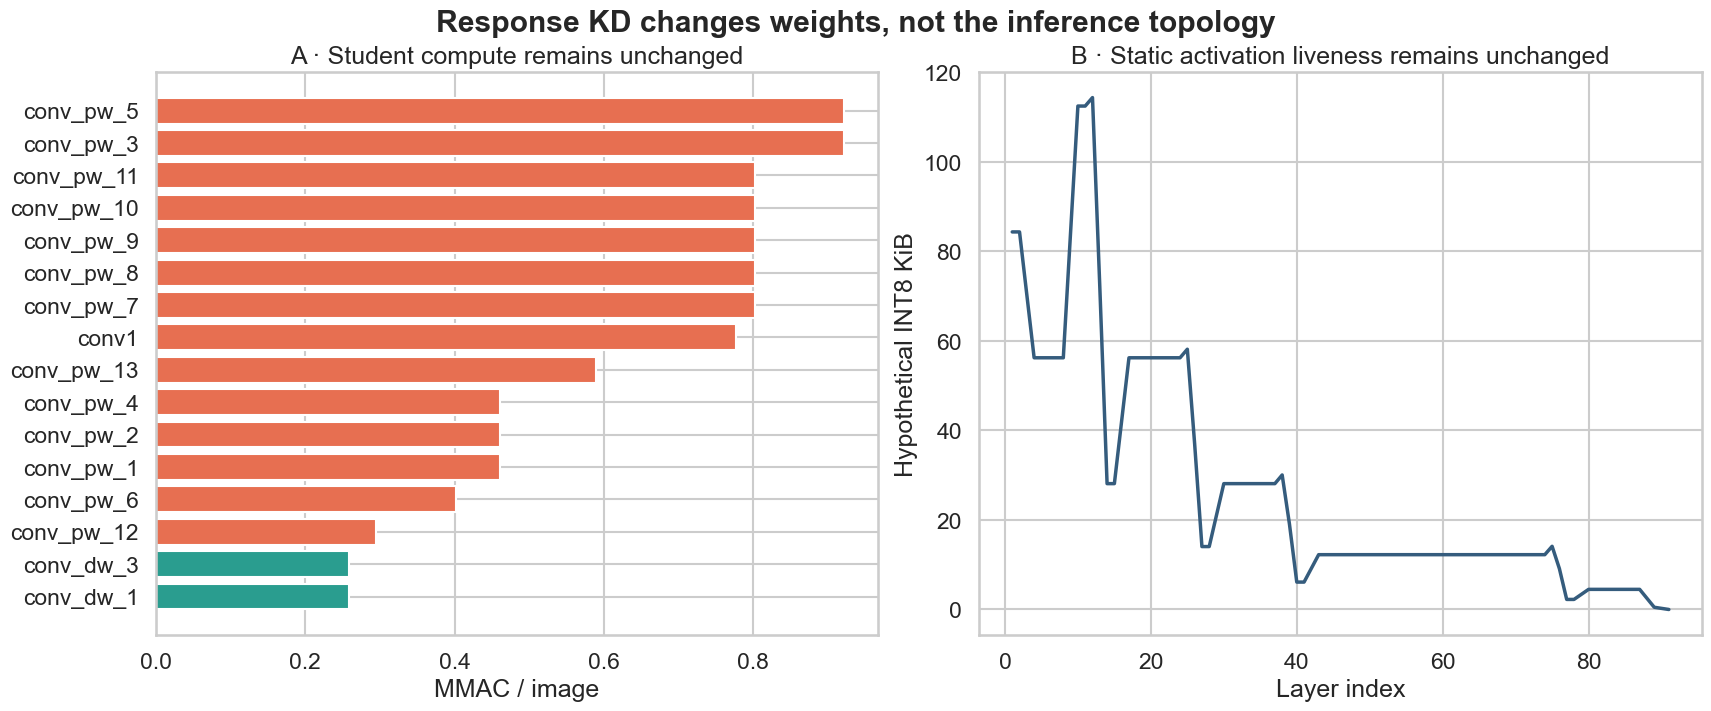

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7), constrained_layout=True)
axes[0].barh(
    top.layer_name, top.estimated_macs_batch1 / 1e6,
    color=np.where(top.layer_type == 'DepthwiseConv2D', '#2A9D8F', '#E76F51'),
)
axes[0].set(title='A · Student compute remains unchanged', xlabel='MMAC / image')
axes[1].plot(liveness.layer_index, liveness.live_int8_bytes_hypothetical / 1024, linewidth=2.5, color='#355C7D')
axes[1].set(title='B · Static activation liveness remains unchanged', xlabel='Layer index', ylabel='Hypothetical INT8 KiB')
fig.suptitle('Response KD changes weights, not the inference topology', fontweight='bold')
fig.savefig(FIGURE_DIR / 'kd_static_graph_invariance.png', dpi=180, bbox_inches='tight')
plt.show()

## 5 · Implement and verify binary response KD

The custom trainer reports the unweighted hard loss, base soft loss, weighted hard/soft components,
regularization, gradient norm, and ordinary quality metrics. This makes it possible to detect a
common implementation error where the $T^2$ term causes one objective to dominate unexpectedly.

In [44]:
class BinaryResponseDistiller(tf.keras.Model):
    def __init__(
            self, 
            student_core, 
            temperature, 
            teacher_weight, 
            label_smoothing
    ):
        super().__init__(name='binary_response_distiller')

        self.student_core = student_core
        # Temperature
        self.temperature = tf.constant(float(temperature), tf.float32)
        # Weight
        self.teacher_weight = tf.constant(float(teacher_weight), tf.float32)
        # Label Smoothing
        self.label_smoothing = tf.constant(float(label_smoothing), tf.float32)
        # Loss
        self.loss_tracker = tf.keras.metrics.Mean(name='loss')
        self.hard_loss_tracker = tf.keras.metrics.Mean(name='hard_loss')
        self.soft_loss_tracker = tf.keras.metrics.Mean(name='soft_loss_kl')
        # Hard
        self.hard_component_tracker = tf.keras.metrics.Mean(name='hard_component')
        # Soft
        self.soft_component_tracker = tf.keras.metrics.Mean(name='soft_component')

        self.regularization_tracker = tf.keras.metrics.Mean(name='regularization')
        self.gradient_norm_tracker = tf.keras.metrics.Mean(name='gradient_norm')

        self.quality_metrics = [
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(curve='ROC', name='roc_auc'),
            tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
        ]

    @property
    def metrics(self):
        return [
            self.loss_tracker, 
            self.hard_loss_tracker, 
            self.soft_loss_tracker,
            self.hard_component_tracker, 
            self.soft_component_tracker,
            self.regularization_tracker, 
            self.gradient_norm_tracker,
            *self.quality_metrics,
        ]

    def call(self, images, training=False):
        return tf.sigmoid(
            self.student_core(images, training=training)
        )

    def _loss_terms(self, labels, teacher_logits, student_logits):
        # Labels
        labels = tf.reshape(tf.cast(labels, tf.float32), (-1, 1))

        # Teacher logits
        teacher_logits = tf.reshape(tf.cast(teacher_logits, tf.float32), (-1, 1))

        # Label smoothing
        smoothed = labels * (1 - self.label_smoothing) + 0.5 * self.label_smoothing

        # HARD LOSS
        hard_loss = tf.reduce_mean(
            tf.nn.sigmoid_cross_entropy_with_logits(
                labels=smoothed, 
                logits=student_logits,
            )
        )

        # Teacher Soft
        teacher_soft = tf.clip_by_value(
            tf.sigmoid(teacher_logits / self.temperature), 
            1e-7, 
            1 - 1e-7
        )

        soft_cross_entropy = tf.reduce_mean(
            tf.nn.sigmoid_cross_entropy_with_logits(
                labels=teacher_soft, 
                logits=student_logits / self.temperature,
            )
        )

        teacher_entropy = tf.reduce_mean(
            -(teacher_soft * tf.math.log(teacher_soft) + (1 - teacher_soft) * tf.math.log(1 - teacher_soft))
        )

        # SOFT LOSS
        soft_loss = soft_cross_entropy - teacher_entropy

        # COMPONETS
        hard_component = (1 - self.teacher_weight) * hard_loss
        soft_component = self.teacher_weight * tf.square(self.temperature) * soft_loss

        regularization = tf.add_n(self.student_core.losses) if self.student_core.losses else tf.constant(0.0)

        # TOTAL
        total = hard_component + soft_component + regularization

        return total, hard_loss, soft_loss, hard_component, soft_component, regularization

    def _update_metrics(self, labels, logits, values, gradient_norm):
        total, hard_loss, soft_loss, hard_component, soft_component, regularization = values
        self.loss_tracker.update_state(total)
        self.hard_loss_tracker.update_state(hard_loss)
        self.soft_loss_tracker.update_state(soft_loss)
        self.hard_component_tracker.update_state(hard_component)
        self.soft_component_tracker.update_state(soft_component)
        self.regularization_tracker.update_state(regularization)
        self.gradient_norm_tracker.update_state(gradient_norm)

        probabilities = tf.sigmoid(logits)
        labels = tf.reshape(tf.cast(labels, tf.float32), (-1, 1))

        for metric in self.quality_metrics:
            metric.update_state(labels, probabilities)

    def train_step(self, data):
        images, targets = data

        with tf.GradientTape() as tape:
            logits = self.student_core(
                images, 
                training=True
            )
            values = self._loss_terms(
                targets['label'], 
                targets['teacher_logit'], 
                logits
            )
        gradients = tape.gradient(
            values[0], 
            self.student_core.trainable_variables
        )
        pairs = [(gradient, variable) for gradient, variable in zip(gradients, self.student_core.trainable_variables) if gradient is not None]

        self.optimizer.apply_gradients(pairs)

        gradient_norm = tf.linalg.global_norm([gradient for gradient, _ in pairs])

        self._update_metrics(
            targets['label'], 
            logits, 
            values, 
            gradient_norm
        )

        return {metric.name: metric.result() for metric in self.metrics}

    def test_step(self, data):
        images, targets = data
        logits = self.student_core(
            images, 
            training=False
        )
        values = self._loss_terms(
            targets['label'], 
            targets['teacher_logit'], 
            logits
        )

        self._update_metrics(
            targets['label'], 
            logits, 
            values, 
            tf.constant(0.0)
        )

        return {metric.name: metric.result() for metric in self.metrics}

In [45]:
# Numerical contract tests catch temperature placement, weighting, and shape mistakes before training.
probe = BinaryResponseDistiller(
    student_core=student_core,
    temperature=TEMPERATURE,
    teacher_weight=TEACHER_WEIGHT,
    label_smoothing=float(config['training']['label_smoothing']),
)

In [46]:
labels_probe = tf.constant([0.0, 1.0])
teacher_probe = tf.constant([-4.0, 4.0])
student_probe = tf.constant([[-1.0], [1.0]])

In [47]:
terms = probe._loss_terms(
    labels_probe, 
    teacher_probe, 
    student_probe
)

In [49]:
assert all(bool(tf.math.is_finite(value)) for value in terms)
assert np.allclose(sigmoid_np(
    np.array([-4.0, 4.0]) / 4.0), 
    [0.26894142, 0.73105858], 
    atol=1e-7
)
assert float(terms[4]) > 0 and float(terms[3]) > 0
print({
    'total': float(terms[0]), 'hard_loss': float(terms[1]),
    'soft_loss_kl': float(terms[2]), 'hard_component': float(terms[3]),
    'soft_component_after_T2': float(terms[4]), 'regularization': float(terms[5]),
})

{'total': 0.6519249677658081, 'hard_loss': 0.32826167345046997, 'soft_loss_kl': 0.06097167730331421, 'hard_component': 0.16413083672523499, 'soft_component_after_T2': 0.48777341842651367, 'regularization': 2.0761048290296458e-05}


In [50]:
student_grid = np.linspace(-8, 8, 401).astype(np.float32)
teacher_examples = [-4.0, 0.0, 4.0]

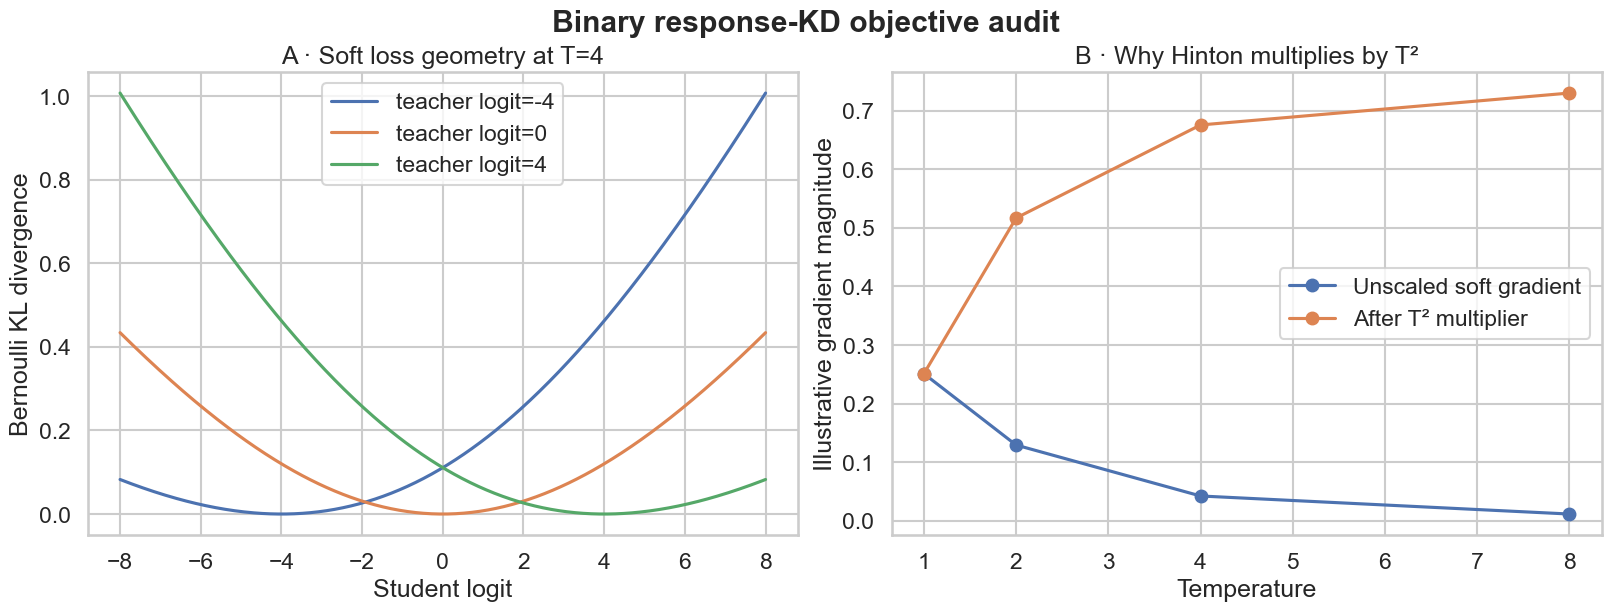

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

for teacher_logit in teacher_examples:
    target = sigmoid_np(teacher_logit / TEMPERATURE)
    soft_bce = -(target * np.log(np.clip(sigmoid_np(student_grid / TEMPERATURE), 1e-7, 1)) +
                 (1 - target) * np.log(np.clip(1 - sigmoid_np(student_grid / TEMPERATURE), 1e-7, 1)))
    teacher_entropy = binary_entropy_np(target)
    
    axes[0].plot(student_grid, soft_bce - teacher_entropy, label=f'teacher logit={teacher_logit:g}')
axes[0].set(title='A · Soft loss geometry at T=4', xlabel='Student logit', ylabel='Bernoulli KL divergence')
axes[0].legend()

temperatures = np.array([1, 2, 4, 8], dtype=float)
unscaled_gradient = []
scaled_gradient = []

for temperature in temperatures:
    q_teacher = sigmoid_np(4 / temperature)
    q_student = sigmoid_np(1 / temperature)
    gradient = abs(q_student - q_teacher) / temperature
    unscaled_gradient.append(gradient)
    scaled_gradient.append(gradient * temperature**2)

axes[1].plot(temperatures, unscaled_gradient, 'o-', label='Unscaled soft gradient')
axes[1].plot(temperatures, scaled_gradient, 'o-', label='After T² multiplier')
axes[1].set(title='B · Why Hinton multiplies by T²', xlabel='Temperature', ylabel='Illustrative gradient magnitude')
axes[1].legend()
fig.suptitle('Binary response-KD objective audit', fontweight='bold')
fig.savefig(FIGURE_DIR / 'response_kd_loss_geometry.png', dpi=180, bbox_inches='tight')
plt.show()

## 6 · Two-stage response-KD training

Stage A trains the binary head with the ImageNet backbone frozen. Stage B fine-tunes the same final
layers as Notebook 01 while keeping BatchNorm frozen. Validation PR-AUC selects checkpoints. Both
stages use the combined hard/soft objective; the test split never controls optimization.

In [53]:
class StudentBestCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, path, monitor='val_pr_auc', mode='max'):
        super().__init__()
        self.path = Path(path)
        self.monitor = monitor
        self.best = -np.inf if mode == 'max' else np.inf
        self.better = (lambda current: current > self.best) if mode == 'max' else (lambda current: current < self.best)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is not None and self.better(float(current)):
            self.best = float(current)
            self.model.student_core.save(self.path)
            print(f'\nSaved student core: {self.path.name} ({self.monitor}={self.best:.6f})')

In [54]:
def training_callbacks(stage, checkpoint_path):
    return [
        StudentBestCheckpoint(
            checkpoint_path, 
            monitor=config['training']['monitor']
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor=config['training']['monitor'], mode='max',
            patience=int(config['training']['early_stopping_patience']),
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor=config['training']['monitor'], 
            mode='max', 
            factor=.3,
            patience=int(config['training']['reduce_lr_patience']), 
            min_lr=1e-7,
        ),
        tf.keras.callbacks.CSVLogger(LOG_DIR / f'{stage}.csv'),
        tf.keras.callbacks.TerminateOnNaN(),
    ]

DISTILLER

In [55]:
def make_distiller(core, learning_rate):
    trainer = BinaryResponseDistiller(
        student_core=core,
        temperature=TEMPERATURE,
        teacher_weight=TEACHER_WEIGHT,
        label_smoothing=float(config['training']['label_smoothing']),
    )
    trainer.compile(optimizer=tf.keras.optimizers.Adam(float(learning_rate)))
    return trainer

In [56]:
for layer in student_core.layers:
    if layer.name in backbone_names:
        layer.trainable = False

In [57]:
STAGE_A = CHECKPOINT_DIR / 'best_stage_a_student_logits.keras'

In [58]:
if STAGE_A.exists() and REUSE_BEST_CHECKPOINT:
    student_core = tf.keras.models.load_model(STAGE_A, compile=False)
    print(f'Reused {STAGE_A.name}')
elif RUN_TRAINING:
    stage_a_trainer = make_distiller(student_core, config['training']['head_learning_rate'])
    stage_a_trainer.fit(
        train_kd_ds,
        validation_data=val_kd_ds,
        epochs=int(config['training']['head_epochs']),
        callbacks=training_callbacks('stage_a', STAGE_A),
    )
    student_core = tf.keras.models.load_model(STAGE_A, compile=False)
else:
    print('Stage A disabled. Set RUN_TRAINING=True to run the T=4, lambda=0.5 anchor.')

Epoch 1/8
374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4834 - gradient_norm: 4.3824 - hard_component: 0.5497 - hard_loss: 1.0995 - loss: 1.2308 - pr_auc: 0.4841 - precision: 0.4731 - recall: 0.3656 - regularization: 1.9693e-05 - roc_auc: 0.4714 - soft_component: 0.6811 - soft_loss_kl: 0.0851
Saved student core: best_stage_a_student_logits.keras (val_pr_auc=0.584906)
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.5146 - gradient_norm: 3.3494 - hard_component: 0.4761 - hard_loss: 0.9522 - loss: 1.0339 - pr_auc: 0.5203 - precision: 0.5157 - recall: 0.4803 - regularization: 1.8724e-05 - roc_auc: 0.5174 - soft_component: 0.5578 - soft_loss_kl: 0.0697 - val_accuracy: 0.5955 - val_gradient_norm: 0.0000e+00 - val_hard_component: 0.3842 - val_hard_loss: 0.7685 - val_loss: 0.8047 - val_pr_auc: 0.5849 - val_precision: 0.5895 - val_recall: 0.5996 - val_regularization: 1.6946e-05 - val_roc_auc: 0.6304 - val_soft_component: 0.4205 - val_soft_loss_kl: 0.0526 - learning_rate: 3.00

In [60]:
STAGE_B = CHECKPOINT_DIR / 'best_stage_b_student_logits.keras'

In [ ]:
if STAGE_B.exists() and REUSE_BEST_CHECKPOINT:
    student_core = tf.keras.models.load_model(STAGE_B, compile=False)
    print(f'Reused {STAGE_B.name}')
elif RUN_TRAINING and STAGE_A.exists():
    student_core = tf.keras.models.load_model(STAGE_A, compile=False)
    mobile_layers = [layer for layer in student_core.layers if layer.name in backbone_names]
    cutoff = max(0, len(mobile_layers) - int(config['training']['fine_tune_last_layers']))
    for index, layer in enumerate(mobile_layers):
        layer.trainable = index >= cutoff and not isinstance(layer, tf.keras.layers.BatchNormalization)
        
    stage_b_trainer = make_distiller(student_core, config['training']['fine_tune_learning_rate'])
    stage_b_trainer.fit(
        train_kd_ds,
        validation_data=val_kd_ds,
        epochs=int(config['training']['fine_tune_epochs']),
        callbacks=training_callbacks('stage_b', STAGE_B),
    )
    student_core = tf.keras.models.load_model(STAGE_B, compile=False)
else:
    print('Stage B disabled or waiting for Stage A.')

Epoch 1/20
256/375 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.6822 - gradient_norm: 11.4915 - hard_component: 0.3085 - hard_loss: 0.6171 - loss: 0.5916 - pr_auc: 0.7479 - precision: 0.6801 - recall: 0.6899 - regularization: 6.5199e-06 - roc_auc: 0.7430 - soft_component: 0.2831 - soft_loss_kl: 0.0354

In [ ]:
FINAL_CORE = MODEL_DIR / 'student_120_response_kd_t4_l050_logits.keras'
FINAL_MODEL = MODEL_DIR / 'student_120_response_kd_t4_l050.keras'

In [ ]:
if STAGE_B.exists():
    student_core = tf.keras.models.load_model(STAGE_B, compile=False)
    student_probability = probability_view(student_core)
    student_core.save(FINAL_CORE)
    student_probability.save(FINAL_MODEL)
    print({'float_model': FINAL_MODEL.name, 'weights_sha256': sha256_weights(student_core)})
else:
    print('Final model awaits Stage B.')

In [ ]:
logs = []
for stage, path in [('head', LOG_DIR / 'stage_a.csv'), ('fine-tune', LOG_DIR / 'stage_b.csv')]:
    if path.exists():
        frame = pd.read_csv(path)
        frame['stage'] = stage
        logs.append(frame)

if logs:
    history = pd.concat(logs, ignore_index=True)
    history['epoch_all'] = np.arange(1, len(history) + 1)
    history.to_csv(REPORT_DIR / 'training_history.csv', index=False)
    fig, axes = plt.subplots(2, 2, figsize=(17, 11), constrained_layout=True)
    for metric, axis in zip(['loss', 'pr_auc', 'hard_component', 'soft_component'], axes.flat):
        axis.plot(history.epoch_all, history[metric], label='train', linewidth=2)
        validation_name = f'val_{metric}'
        if validation_name in history:
            axis.plot(history.epoch_all, history[validation_name], label='validation', linewidth=2)
        axis.set(title=metric.replace('_', ' ').title(), xlabel='Combined epoch')
        axis.legend()
    fig.suptitle('Response-KD optimization diagnostics', fontweight='bold')
    fig.savefig(FIGURE_DIR / 'response_kd_learning_curves.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    print('Learning curves await training.')

## 7 · Frozen evaluation against the hard-label control

The operating threshold is selected independently on validation for each model under the same
minimum-recall constraint, then frozen for the test set. PR-AUC remains the primary threshold-free
comparison. A paired bootstrap estimates uncertainty in KD-minus-control deltas.

In [ ]:
def predict_probability(model, dataset):
    labels = np.concatenate([np.asarray(label).reshape(-1) for _, label in dataset]).astype(np.int8)
    probabilities = model.predict(dataset, verbose=0).reshape(-1).astype(np.float32)
    return labels, probabilities


def evaluate_with_validation_threshold(model):
    y_val, p_val = predict_probability(model, val_ds)
    choice = select_threshold(
        y_val, p_val,
        objective=config['evaluation']['threshold_objective'],
        minimum_recall=float(config['evaluation']['minimum_recall']),
        false_positive_cost=float(config['evaluation']['false_positive_cost']),
        false_negative_cost=float(config['evaluation']['false_negative_cost']),
    )
    threshold = float(choice['threshold'])
    y_test, p_test = predict_probability(model, test_ds)
    metrics = classification_metrics(y_test, p_test, threshold)
    metrics['ece_10'] = expected_calibration_error(y_test, p_test, bins=int(config['evaluation']['calibration_bins']))
    return threshold, y_val, p_val, y_test, p_test, metrics

In [ ]:
MODEL_READY = FINAL_MODEL.exists()
control_threshold, yc_val, pc_val, yc_test, pc_test, control_metrics_recomputed = evaluate_with_validation_threshold(control_model)
assert np.array_equal(yc_test, splits['test'].label.to_numpy(dtype=np.int8))

if MODEL_READY:
    kd_model = tf.keras.models.load_model(FINAL_MODEL, compile=False)
    KD_THRESHOLD, yk_val, pk_val, y_test, pk_test, kd_metrics = evaluate_with_validation_threshold(kd_model)
    assert np.array_equal(y_test, yc_test)
    (REPORT_DIR / 'validation_threshold.json').write_text(json.dumps({'threshold': KD_THRESHOLD}, indent=2) + '\n')
    (REPORT_DIR / 'test_metrics_float.json').write_text(json.dumps(kd_metrics, indent=2) + '\n')
    display(pd.DataFrame([
        {'model': 'Hard control', **control_metrics_recomputed},
        {'model': 'Response KD', **kd_metrics},
    ]).drop(columns=['confusion_matrix']).set_index('model'))
else:
    KD_THRESHOLD = kd_metrics = y_test = pk_test = None
    print('KD evaluation awaits training; hard-control prediction contract passed.')

In [ ]:
def paired_bootstrap_deltas(labels, control_prob, kd_prob, control_threshold, kd_threshold, samples, seed):
    rng = np.random.default_rng(seed)
    rows = []
    labels = np.asarray(labels)
    for iteration in range(samples):
        index = rng.integers(0, len(labels), len(labels))
        y = labels[index]
        if np.unique(y).size < 2:
            continue
        control_sample = control_prob[index]
        kd_sample = kd_prob[index]
        rows.append({
            'iteration': iteration,
            'pr_auc_delta': average_precision_score(y, kd_sample) - average_precision_score(y, control_sample),
            'f1_delta': f1_score(y, kd_sample >= kd_threshold) - f1_score(y, control_sample >= control_threshold),
        })
    return pd.DataFrame(rows)


if MODEL_READY and RUN_BOOTSTRAP:
    bootstrap = paired_bootstrap_deltas(
        y_test, pc_test, pk_test, control_threshold, KD_THRESHOLD,
        int(config['evaluation']['bootstrap_samples']), SEED,
    )
    bootstrap.to_csv(REPORT_DIR / 'paired_bootstrap_quality_deltas.csv', index=False)
    bootstrap_summary = bootstrap[['pr_auc_delta', 'f1_delta']].agg(
        ['mean', lambda values: values.quantile(.025), lambda values: values.quantile(.975)]
    )
    bootstrap_summary.index = ['mean', 'q025', 'q975']
    display(bootstrap_summary.style.format('{:+.4f}'))
else:
    bootstrap = bootstrap_summary = None
    print('Paired bootstrap awaits the KD model.')

In [ ]:
if MODEL_READY:
    fig, axes = plt.subplots(2, 2, figsize=(16, 13), constrained_layout=True)
    sns.heatmap(np.asarray(control_metrics_recomputed['confusion_matrix']), annot=True, fmt='d', cbar=False, ax=axes[0, 0], cmap='Blues')
    axes[0, 0].set(title=f'A · Hard control @ {control_threshold:.3f}', xlabel='Predicted', ylabel='True')
    sns.heatmap(np.asarray(kd_metrics['confusion_matrix']), annot=True, fmt='d', cbar=False, ax=axes[0, 1], cmap='GnBu')
    axes[0, 1].set(title=f'B · Response KD @ {KD_THRESHOLD:.3f}', xlabel='Predicted', ylabel='True')

    for name, probabilities, color in [('Hard control', pc_test, '#E76F51'), ('Response KD', pk_test, '#00A6D6')]:
        precision, recall, _ = precision_recall_curve(y_test, probabilities)
        axes[1, 0].plot(recall, precision, label=f'{name} · AP={average_precision_score(y_test, probabilities):.3f}', color=color, linewidth=2.5)
        predicted, observed = calibration_points(y_test, probabilities, bins=int(config['evaluation']['calibration_bins']))
        axes[1, 1].plot(predicted, observed, 'o-', label=name, color=color, linewidth=2)
    axes[1, 0].set(title='C · Frozen test precision-recall', xlabel='Recall', ylabel='Precision')
    axes[1, 0].legend()
    axes[1, 1].plot([0, 1], [0, 1], '--', color='#555555', label='Ideal')
    axes[1, 1].set(title='D · Reliability diagram', xlabel='Mean confidence', ylabel='Observed frequency')
    axes[1, 1].legend()
    fig.suptitle('Hard-label control versus Hinton/MicroNets response KD', fontweight='bold')
    fig.savefig(FIGURE_DIR / 'control_vs_response_kd_quality.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    print('Quality comparison figures await training.')

In [ ]:
if MODEL_READY:
    agreement = splits['test'][[
        'image_id', 'label', 'teacher_probability', 'teacher_logit',
        'max_person_area_fraction', 'image_path',
    ]].copy()
    agreement['control_probability'] = pc_test
    agreement['kd_probability'] = pk_test
    teacher_threshold = float(teacher_summary['validation_threshold'])
    agreement['teacher_correct'] = ((agreement.teacher_probability >= teacher_threshold).astype(int) == agreement.label)
    agreement['control_correct'] = ((agreement.control_probability >= control_threshold).astype(int) == agreement.label)
    agreement['kd_correct'] = ((agreement.kd_probability >= KD_THRESHOLD).astype(int) == agreement.label)
    agreement['kd_fixed_control'] = agreement.kd_correct & ~agreement.control_correct
    agreement['kd_broke_control'] = ~agreement.kd_correct & agreement.control_correct
    agreement.to_csv(REPORT_DIR / 'test_teacher_control_kd_agreement.csv', index=False)

    diagnostic = {
        'teacher_correct_control_wrong': int((agreement.teacher_correct & ~agreement.control_correct).sum()),
        'teacher_correct_kd_wrong': int((agreement.teacher_correct & ~agreement.kd_correct).sum()),
        'kd_fixed_control': int(agreement.kd_fixed_control.sum()),
        'kd_broke_control': int(agreement.kd_broke_control.sum()),
        'kd_teacher_probability_mae': float(np.mean(np.abs(agreement.teacher_probability - agreement.kd_probability))),
        'control_teacher_probability_mae': float(np.mean(np.abs(agreement.teacher_probability - agreement.control_probability))),
    }
    display(pd.Series(diagnostic))

    fig, axes = plt.subplots(1, 3, figsize=(19, 6), constrained_layout=True)
    axes[0].scatter(agreement.teacher_probability, agreement.control_probability, c=agreement.label, cmap='coolwarm', alpha=.25, s=14)
    axes[0].plot([0, 1], [0, 1], '--', color='#555555')
    axes[0].set(title='A · Teacher vs hard control', xlabel='Teacher probability', ylabel='Control probability')
    axes[1].scatter(agreement.teacher_probability, agreement.kd_probability, c=agreement.label, cmap='coolwarm', alpha=.25, s=14)
    axes[1].plot([0, 1], [0, 1], '--', color='#555555')
    axes[1].set(title='B · Teacher vs response KD', xlabel='Teacher probability', ylabel='KD probability')
    axes[2].bar(['KD fixed control', 'KD broke control'], [diagnostic['kd_fixed_control'], diagnostic['kd_broke_control']], color=['#2A9D8F', '#E76F51'])
    axes[2].set(title='C · Paired decision changes', ylabel='Frozen test images')
    fig.suptitle('Did teacher knowledge change the right examples?', fontweight='bold')
    fig.savefig(FIGURE_DIR / 'teacher_control_kd_agreement.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    diagnostic = agreement = None
    print('Teacher/control/KD diagnostic awaits training.')

In [ ]:
if MODEL_READY:
    positive = agreement[agreement.label == 1].copy()
    positive['person_size'] = pd.cut(
        positive.max_person_area_fraction,
        bins=[-np.inf, .02, .10, np.inf],
        labels=['small', 'medium', 'large'],
    )
    size_rows = []
    for size, frame in positive.groupby('person_size', observed=True):
        size_rows.append({
            'person_size': str(size), 'samples': len(frame),
            'control_recall': np.mean(frame.control_probability >= control_threshold),
            'kd_recall': np.mean(frame.kd_probability >= KD_THRESHOLD),
        })
    size_quality = pd.DataFrame(size_rows)
    size_quality['recall_delta'] = size_quality.kd_recall - size_quality.control_recall
    size_quality.to_csv(REPORT_DIR / 'person_size_kd_delta.csv', index=False)
    display(size_quality.style.format({
        'control_recall': '{:.2%}', 'kd_recall': '{:.2%}', 'recall_delta': '{:+.2%}',
    }))

    x = np.arange(len(size_quality))
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(x - .18, size_quality.control_recall * 100, .36, label='Hard control', color='#E76F51')
    ax.bar(x + .18, size_quality.kd_recall * 100, .36, label='Response KD', color='#00A6D6')
    ax.set_xticks(x, size_quality.person_size.str.title())
    ax.set(title='Person-size recall: the critical VWW failure slice', ylabel='Recall (%)')
    ax.legend()
    fig.savefig(FIGURE_DIR / 'person_size_control_vs_kd.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    size_quality = None
    print('Error-slice analysis awaits training.')

## 8 · Full-INT8 export and graph-identity check

Distillation is removed at export: no teacher, temperature operation, or KD loss may appear in the
FlatBuffer. The clean inference graph is rebuilt without random augmentation, receives the learned
weights, and is converted with the same full-INT8 PTQ path as Notebook 01.

In [ ]:
TFLITE_PATH = MODEL_DIR / config['export']['model_filename']

In [ ]:
def build_deploy_student(source_core):
    inputs = tf.keras.Input((*STUDENT_SIZE, 3), name='image')
    x = tf.keras.layers.Rescaling(1 / 127.5, offset=-1, name='normalize')(inputs)
    backbone = tf.keras.applications.MobileNet(
        input_tensor=x,
        input_shape=(*STUDENT_SIZE, 3),
        alpha=float(config['student']['width_multiplier']),
        include_top=False,
        weights=None,
    )
    x = tf.keras.layers.GlobalAveragePooling2D(name='global_average')(backbone.output)
    logits = tf.keras.layers.Dense(1, name='person_logit')(x)
    outputs = tf.keras.layers.Activation('sigmoid', name='person_probability')(logits)
    deploy = tf.keras.Model(inputs, outputs, name='vww_student_120_a025_response_kd_deploy')
    for layer in deploy.layers:
        if not layer.weights:
            continue
        source = source_core.get_layer(layer.name)
        assert [tuple(weight.shape) for weight in layer.weights] == [tuple(weight.shape) for weight in source.weights]
        layer.set_weights(source.get_weights())
    return deploy


if MODEL_READY and RUN_EXPORT:
    source_core = tf.keras.models.load_model(FINAL_CORE, compile=False)
    kd_model = tf.keras.models.load_model(FINAL_MODEL, compile=False)
    deploy_student = build_deploy_student(source_core)
    parity_batch = next(iter(val_ds))[0]
    deploy_graph_mae = float(tf.reduce_mean(tf.abs(
        kd_model(parity_batch, training=False) - deploy_student(parity_batch, training=False)
    )))
    assert deploy_graph_mae < 1e-6, deploy_graph_mae
    deploy_student.save(MODEL_DIR / 'student_120_response_kd_t4_l050_deploy.keras')

    representative = splits['train'].sample(
        n=min(int(config['export']['representative_samples']), len(splits['train'])),
        random_state=SEED,
    )
    representative_ds = make_eval_dataset(representative, batch_size=1)

    def representative_data():
        for batch, _ in representative_ds:
            yield [batch.numpy().astype(np.float32)]

    convert_full_integer(deploy_student, representative_data(), TFLITE_PATH)
    print({'deploy_graph_mae': deploy_graph_mae, 'tflite': TFLITE_PATH.name})
else:
    deploy_graph_mae = None
    print('INT8 export awaits a trained KD model.')

In [ ]:
export_info = inspect_tflite(TFLITE_PATH) if TFLITE_PATH.exists() else None
control_export_info = json.loads((CONTROL_SUMMARY_PATH.parent / 'export_info.json').read_text())
if export_info:
    assert export_info['input']['dtype'] == 'int8'
    assert export_info['output']['dtype'] == 'int8'
    assert export_info['operators'] == control_export_info['operators']
    graph_identity = {
        'parameters_equal': static_profile['parameters'] == control_static['parameters'],
        'macs_equal': static_profile['estimated_macs_batch1'] == control_static['estimated_macs_batch1'],
        'peak_activation_estimate_equal': (
            static_profile['peak_live_activation_int8_bytes_batch1_hypothetical'] ==
            control_static['peak_live_activation_int8_bytes_batch1_hypothetical']
        ),
        'operator_set_equal': export_info['operators'] == control_export_info['operators'],
        'control_tflite_bytes': control_export_info['size_bytes'],
        'kd_tflite_bytes': export_info['size_bytes'],
    }
    (REPORT_DIR / 'export_info.json').write_text(json.dumps(export_info, indent=2) + '\n')
    (REPORT_DIR / 'graph_identity.json').write_text(json.dumps(graph_identity, indent=2) + '\n')
    display(pd.Series(graph_identity))
else:
    graph_identity = None
    print('Graph-identity export audit awaits the INT8 model.')

In [ ]:
def predict_tflite(path, dataset):
    interpreter = tf.lite.Interpreter(model_path=str(path))
    interpreter.allocate_tensors()
    input_detail = interpreter.get_input_details()[0]
    output_detail = interpreter.get_output_details()[0]
    input_scale, input_zero = input_detail['quantization']
    output_scale, output_zero = output_detail['quantization']
    labels, probabilities = [], []
    for batch, truth in dataset:
        for image, label in zip(batch.numpy(), truth.numpy()):
            quantized = np.clip(np.round(image / input_scale + input_zero), -128, 127).astype(np.int8)[None]
            interpreter.set_tensor(input_detail['index'], quantized)
            interpreter.invoke()
            raw = interpreter.get_tensor(output_detail['index'])[0, 0]
            labels.append(int(label))
            probabilities.append((float(raw) - output_zero) * output_scale)
    return np.asarray(labels), np.asarray(probabilities)

In [ ]:
if MODEL_READY and export_info:
    yi_val, pi_val = predict_tflite(TFLITE_PATH, val_ds)
    int8_choice = select_threshold(
        yi_val, pi_val,
        objective=config['evaluation']['threshold_objective'],
        minimum_recall=float(config['evaluation']['minimum_recall']),
        false_positive_cost=float(config['evaluation']['false_positive_cost']),
        false_negative_cost=float(config['evaluation']['false_negative_cost']),
    )
    INT8_THRESHOLD = float(int8_choice['threshold'])
    yi_test, pi_test = predict_tflite(TFLITE_PATH, test_ds)
    int8_metrics = classification_metrics(yi_test, pi_test, INT8_THRESHOLD)
    int8_metrics['ece_10'] = expected_calibration_error(yi_test, pi_test, bins=int(config['evaluation']['calibration_bins']))
    parity = {
        'probability_mae': float(np.mean(np.abs(pk_test - pi_test))),
        'f1_delta': float(int8_metrics['f1'] - kd_metrics['f1']),
        'pr_auc_delta': float(int8_metrics['pr_auc'] - kd_metrics['pr_auc']),
    }
    (REPORT_DIR / 'test_metrics_int8.json').write_text(json.dumps(int8_metrics, indent=2) + '\n')
    (REPORT_DIR / 'float_to_int8_parity.json').write_text(json.dumps(parity, indent=2) + '\n')
    display(pd.Series(parity))
else:
    INT8_THRESHOLD = int8_metrics = parity = None
    print('INT8 quality evaluation awaits export.')

## 9 · Quality-versus-efficiency dashboard

Accuracy improvement is not hardware improvement. Because the graph is fixed, parameters, MACs,
static activation estimates, and expected device latency should remain approximately unchanged.
Only a new physical ESP32 measurement may confirm latency equivalence.

In [ ]:
if MODEL_READY:
    quality_rows = [
        {'model': 'Teacher-160 float', **teacher_summary['test_metrics']},
        {'model': 'Student-120 hard control', **control_metrics_recomputed},
        {'model': 'Student-120 response KD', **kd_metrics},
    ]
    if int8_metrics:
        quality_rows.append({'model': 'Student-120 response KD INT8', **int8_metrics})
    quality = pd.DataFrame(quality_rows)
    quality.to_csv(REPORT_DIR / 'quality_comparison.csv', index=False)
    display(quality[['model', 'accuracy', 'precision', 'recall', 'specificity', 'f1', 'roc_auc', 'pr_auc', 'ece_10']].style.format({
        key: '{:.2%}' for key in ['accuracy', 'precision', 'recall', 'specificity', 'f1', 'roc_auc', 'pr_auc', 'ece_10']
    }).background_gradient(subset=['accuracy', 'f1', 'pr_auc'], cmap='YlGn'))
else:
    quality = None
    print('Quality dashboard awaits training.')

In [ ]:
if MODEL_READY:
    metrics = ['accuracy', 'precision', 'recall', 'specificity', 'f1', 'pr_auc']
    plot_quality = quality.set_index('model')[metrics].astype(float) * 100
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
    x = np.arange(len(metrics))
    width = .24
    palette = ['#355C7D', '#E76F51', '#00A6D6', '#2A9D8F']
    for index, (name, row) in enumerate(plot_quality.iterrows()):
        axes[0].bar(x + (index - (len(plot_quality) - 1) / 2) * width, row, width, label=name, color=palette[index])
    axes[0].set_xticks(x, [metric.replace('_', '\n').title() for metric in metrics])
    axes[0].set_ylim(40, 100)
    axes[0].set(title='A · Frozen test quality', ylabel='Metric (%)')
    axes[0].legend(fontsize=9)

    deltas = pd.Series({
        'Accuracy': kd_metrics['accuracy'] - control_metrics_recomputed['accuracy'],
        'Precision': kd_metrics['precision'] - control_metrics_recomputed['precision'],
        'Recall': kd_metrics['recall'] - control_metrics_recomputed['recall'],
        'Specificity': kd_metrics['specificity'] - control_metrics_recomputed['specificity'],
        'F1': kd_metrics['f1'] - control_metrics_recomputed['f1'],
        'PR-AUC': kd_metrics['pr_auc'] - control_metrics_recomputed['pr_auc'],
    }) * 100
    colors = np.where(deltas >= 0, '#2A9D8F', '#E76F51')
    axes[1].barh(deltas.index, deltas.values, color=colors)
    axes[1].axvline(0, color='#333333', linewidth=1)
    axes[1].set(title='B · Response KD minus hard control', xlabel='Percentage-point change')
    for patch, value in zip(axes[1].patches, deltas.values):
        axes[1].text(value + (.08 if value >= 0 else -.08), patch.get_y() + patch.get_height()/2,
                     f'{value:+.2f}', va='center', ha='left' if value >= 0 else 'right')
    fig.suptitle('Does paper-derived response KD improve the fixed student?', fontweight='bold')
    fig.savefig(FIGURE_DIR / 'response_kd_quality_delta_dashboard.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    print('Quality-delta figure awaits training.')

In [ ]:
efficiency = pd.DataFrame([
    {
        'model': 'Hard control',
        'parameters': control_static['parameters'],
        'macs': control_static['estimated_macs_batch1'],
        'peak_live_int8_estimate_bytes': control_static['peak_live_activation_int8_bytes_batch1_hypothetical'],
        'tflite_bytes': control_export_info['size_bytes'],
        'physical_latency': 'measured previously',
    },
    {
        'model': 'Response KD',
        'parameters': static_profile['parameters'],
        'macs': static_profile['estimated_macs_batch1'],
        'peak_live_int8_estimate_bytes': static_profile['peak_live_activation_int8_bytes_batch1_hypothetical'],
        'tflite_bytes': export_info['size_bytes'] if export_info else np.nan,
        'physical_latency': 'pending exact artifact',
    },
])
efficiency.to_csv(REPORT_DIR / 'static_efficiency_invariance.csv', index=False)
display(efficiency.style.format({
    'parameters': '{:,.0f}', 'macs': '{:,.0f}',
    'peak_live_int8_estimate_bytes': '{:,.0f}', 'tflite_bytes': '{:,.0f}',
}))

In [ ]:
if TFLITE_PATH.exists():
    print('After connecting the intended board, profile the exact artifact with one command at a time:')
    print(f"ESP32-CAM: scripts/profile_esp32_model.sh '{TFLITE_PATH.relative_to(ROOT)}' 120 10487648 245760 response_kd_t4_l050")
    print(f"ESP32-S3:  scripts/profile_esp32_s3_model.sh '{TFLITE_PATH.relative_to(ROOT)}' 120 10487648 245760 response_kd_t4_l050 /dev/cu.<PORT>")
else:
    print('Physical profiling commands will become available after INT8 export.')

## 10 · Acceptance gates and registered ablations

The anchor is promoted only if it improves PR-AUC without an unacceptable F1 regression, preserves
the static graph, and survives INT8 conversion. Physical latency is a separate deployment gate.
Failure of the anchor does not justify silently changing several variables: run the registered
temperature/weight ablations one at a time with distinct artifact directories.

In [ ]:
if MODEL_READY and int8_metrics:
    gates = {
        'float_pr_auc_gain': (
            kd_metrics['pr_auc'] - control_metrics_recomputed['pr_auc'] >=
            float(config['acceptance_gate']['minimum_float_pr_auc_gain'])
        ),
        'float_f1_retained': (
            kd_metrics['f1'] - control_metrics_recomputed['f1'] >=
            -float(config['acceptance_gate']['maximum_float_f1_drop'])
        ),
        'static_graph_identity': all([
            graph_identity['parameters_equal'], graph_identity['macs_equal'],
            graph_identity['peak_activation_estimate_equal'], graph_identity['operator_set_equal'],
        ]),
        'int8_probability_parity': (
            parity['probability_mae'] <=
            float(config['acceptance_gate']['maximum_float_to_int8_probability_mae'])
        ),
        'int8_f1_retained': (
            parity['f1_delta'] >= -float(config['acceptance_gate']['maximum_int8_f1_drop'])
        ),
        'physical_device_profile_complete': False,
    }
    accepted_for_next_distillation_stage = all(value for key, value in gates.items() if key != 'physical_device_profile_complete')
    summary = {
        'experiment': config['project']['name'],
        'paper_anchor': {'temperature': TEMPERATURE, 'teacher_loss_weight': TEACHER_WEIGHT},
        'runtime_contract': runtime_contract,
        'initialization_sha256': initialization_sha256,
        'float_test_metrics': kd_metrics,
        'control_test_metrics_recomputed': control_metrics_recomputed,
        'int8_test_metrics': int8_metrics,
        'quality_delta': {
            'pr_auc': kd_metrics['pr_auc'] - control_metrics_recomputed['pr_auc'],
            'f1': kd_metrics['f1'] - control_metrics_recomputed['f1'],
            'accuracy': kd_metrics['accuracy'] - control_metrics_recomputed['accuracy'],
        },
        'float_to_int8_parity': parity,
        'static_profile': static_profile,
        'graph_identity': graph_identity,
        'distillation_diagnostic': diagnostic,
        'gates': gates,
        'accepted_for_next_distillation_stage': bool(accepted_for_next_distillation_stage),
    }
    (REPORT_DIR / 'experiment_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
    report = f'''# Student-120 response-KD report

- Technique: Hinton binary response KD
- MicroNets anchor: T={TEMPERATURE:g}, lambda={TEACHER_WEIGHT:g}
- Float PR-AUC delta versus hard control: {summary['quality_delta']['pr_auc']:+.4f}
- Float F1 delta versus hard control: {summary['quality_delta']['f1']:+.4f}
- INT8 probability MAE versus float KD: {parity['probability_mae']:.5f}
- Parameters / MACs: {static_profile['parameters']:,} / {static_profile['estimated_macs_batch1']:,}
- Static graph identity: **{gates['static_graph_identity']}**
- Accepted before physical profiling: **{accepted_for_next_distillation_stage}**
- Physical device profiling complete: **{gates['physical_device_profile_complete']}**
'''
    (REPORT_DIR / 'RESPONSE_KD_REPORT.md').write_text(report)
    display(Markdown(report))
else:
    gates = summary = None
    print('Acceptance report awaits training and INT8 evaluation.')

In [ ]:
ablations = pd.DataFrame(config['distillation']['ablations'])
ablations['role'] = [
    'Notebook 01 baseline', 'temperature control', 'temperature control',
    'primary MicroNets anchor', 'teacher-weight control', 'teacher-weight control',
]
ablations['status'] = np.where(ablations.name == 't4_l050', 'implemented here', 'registered; run separately')
display(ablations.style.format({'temperature': '{:.1f}', 'teacher_loss_weight': '{:.2f}'}))

## Next decision

1. Run the primary `T=4, lambda=0.5` anchor and inspect the paired bootstrap, calibration, and
   small-person recall—not accuracy alone.
2. If it improves the hard control, export and physically profile the exact INT8 artifact on both
   boards. Latency should be similar because the graph is identical, but it must be measured.
3. Run only the registered temperature/weight ablations needed to explain the anchor result.
4. Promote the strongest float KD checkpoint to the later structured-pruning recovery experiment;
   apply QAT only after choosing the final compressed topology.

Do not claim that response KD improves latency, SRAM, or flash. It is an accuracy-transfer method;
hardware efficiency requires graph/operator optimization, structured pruning, or architecture search.